# CreditMate walkthrough

This notebook walks through the prototype one step at a time: simulate farmers, see why a land title is a weak signal, train a model on farm data, and turn its predictions into scores and financing offers.

**All data here is simulated.** The point is the method, not the numbers.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
from sklearn.model_selection import train_test_split
from IPython.display import Image, display

from creditmate import charts, model, scorecard, simulate

farmers = simulate.simulate_farmers(n=5000, seed=42)
farmers.head()

,farmer_id,land_acres,has_land_title,crop,irrigation,yield_index,yield_volatility,herd_size,herd_condition,wallet_months,mobile_inflow_pkr,sells_through_arthi,seasonal_income_pkr,default_12m
0,F00001,4.9,False,wheat,diesel_tubewell,1.321,0.105,4,2.5,32,50400.0,False,404000.0,False
1,F00002,2.1,False,wheat,canal,0.985,0.187,3,2.5,34,2600.0,False,165000.0,False
2,F00003,6.6,False,wheat,solar_pump,1.011,0.144,4,4.0,27,21200.0,True,464000.0,True
3,F00004,7.5,False,wheat,diesel_tubewell,0.735,0.293,3,1.0,11,22800.0,True,298000.0,True
4,F00005,1.1,True,wheat,diesel_tubewell,0.903,0.200,4,2.5,10,5800.0,True,132000.0,False


## 1. A land title says little about who repays

Larger farms are more likely to hold a title. But in this simulation repayment depends on what the farm produces, so farmers with and without titles default at about the same rate.

In [2]:
farmers.groupby("has_land_title")["default_12m"].agg(farmers="size", default_rate="mean").round(3)

,farmers,default_rate
has_land_title,,
False,3421,0.198
True,1579,0.202


## 2. What the model learns from

Yields and their stability, herd size and condition, mobile-wallet history and inflows, and whether the farmer sells through an arthi. Land size and land titles are left out on purpose.

In [3]:
X = model.build_features(farmers)
X.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
yield_index,5000.0,1.00,0.18,0.40,0.88,1.00,1.12,1.68
yield_volatility,5000.0,0.22,0.08,0.04,0.17,0.22,0.28,0.54
has_livestock,5000.0,0.91,0.28,0.00,1.00,1.00,1.00,1.00
herd_size,5000.0,2.72,1.86,0.00,1.00,2.00,4.00,15.00
herd_condition,5000.0,3.01,0.77,1.00,2.50,3.00,3.50,5.00
wallet_months,5000.0,18.20,10.64,0.00,9.00,18.00,27.00,36.00
log_mobile_inflow,5000.0,9.83,1.78,0.00,9.51,10.09,10.61,13.09
sells_through_arthi,5000.0,0.54,0.50,0.00,0.00,1.00,1.00,1.00


## 3. Train, choose a cutoff, then test

Farmers are split 60/20/20. The model learns on the first group. The approval cutoff is chosen on the second so that at most 10% of approved farmers default. Every result below comes from the third group, which the model never saw.

In [4]:
train, rest = train_test_split(farmers, test_size=0.4, stratify=farmers["default_12m"], random_state=7)
valid, test = train_test_split(rest, test_size=0.5, stratify=rest["default_12m"], random_state=7)

fitted = model.train_model(model.build_features(train), train["default_12m"].astype(int))

pd_valid = fitted.predict_proba(model.build_features(valid))[:, 1]
cutoff = model.cutoff_for_default_rate(pd_valid, valid["default_12m"].to_numpy(), 0.10)

pd_test = fitted.predict_proba(model.build_features(test))[:, 1]
y_test = test["default_12m"].to_numpy().astype(int)
results = model.compare_with_collateral(test, pd_test, y_test, cutoff)

print(f"AUC on test farmers: {results['auc_farm_data_model']:.2f}")
pd.DataFrame({k: results[k] for k in ["land_title_rule", "model_at_same_approval_rate", "model_at_target_default_rate"]}).T.round(3)

AUC on test farmers: 0.75


,approved_count,approval_rate,default_rate_approved,share_approved_without_title
land_title_rule,193.0,0.193,0.181,0.000
model_at_same_approval_rate,193.0,0.193,0.083,0.715
model_at_target_default_rate,571.0,0.571,0.088,0.704


Approving the same share of farmers as the land-title rule, the model halves the default rate and most of the farmers it approves have no title.

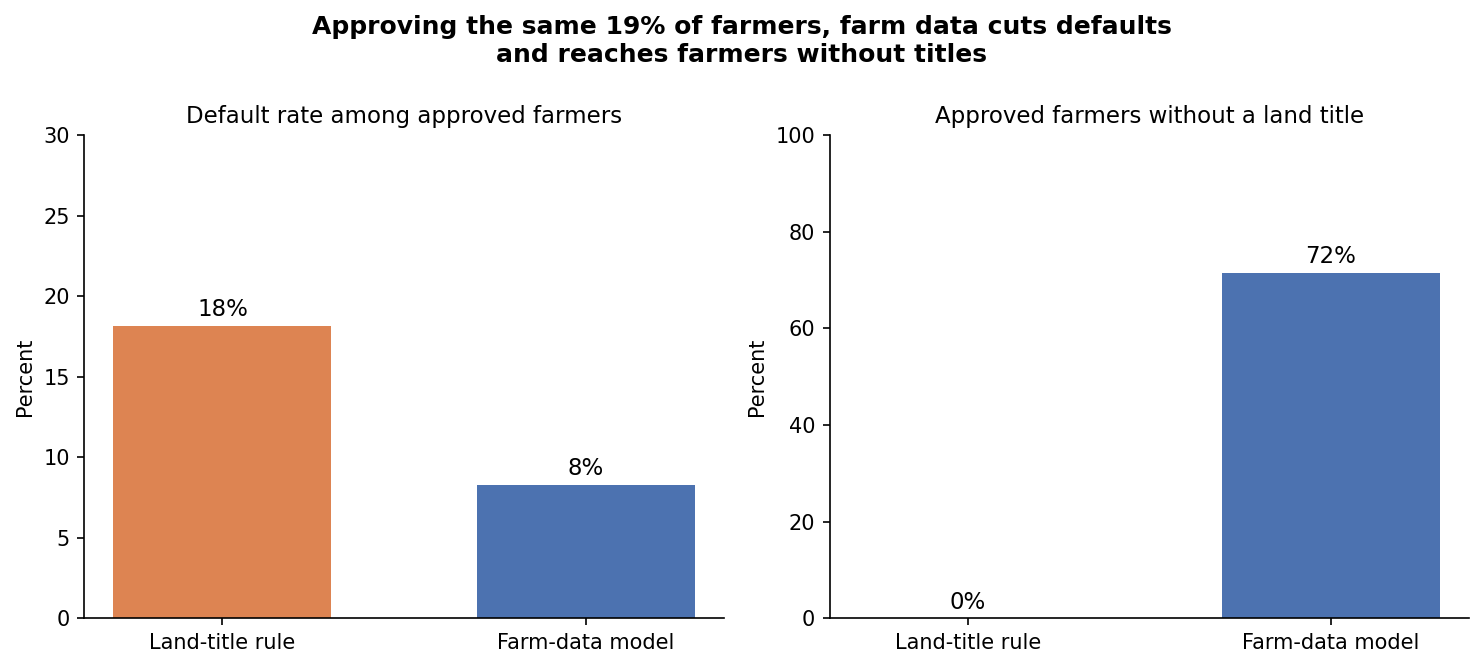

In [5]:
charts.comparison_chart(results, "../outputs/comparison.png")
display(Image("../outputs/comparison.png"))

## 4. What drives risk

Standardized logistic-regression coefficients: positive values raise the probability of default, negative values lower it.

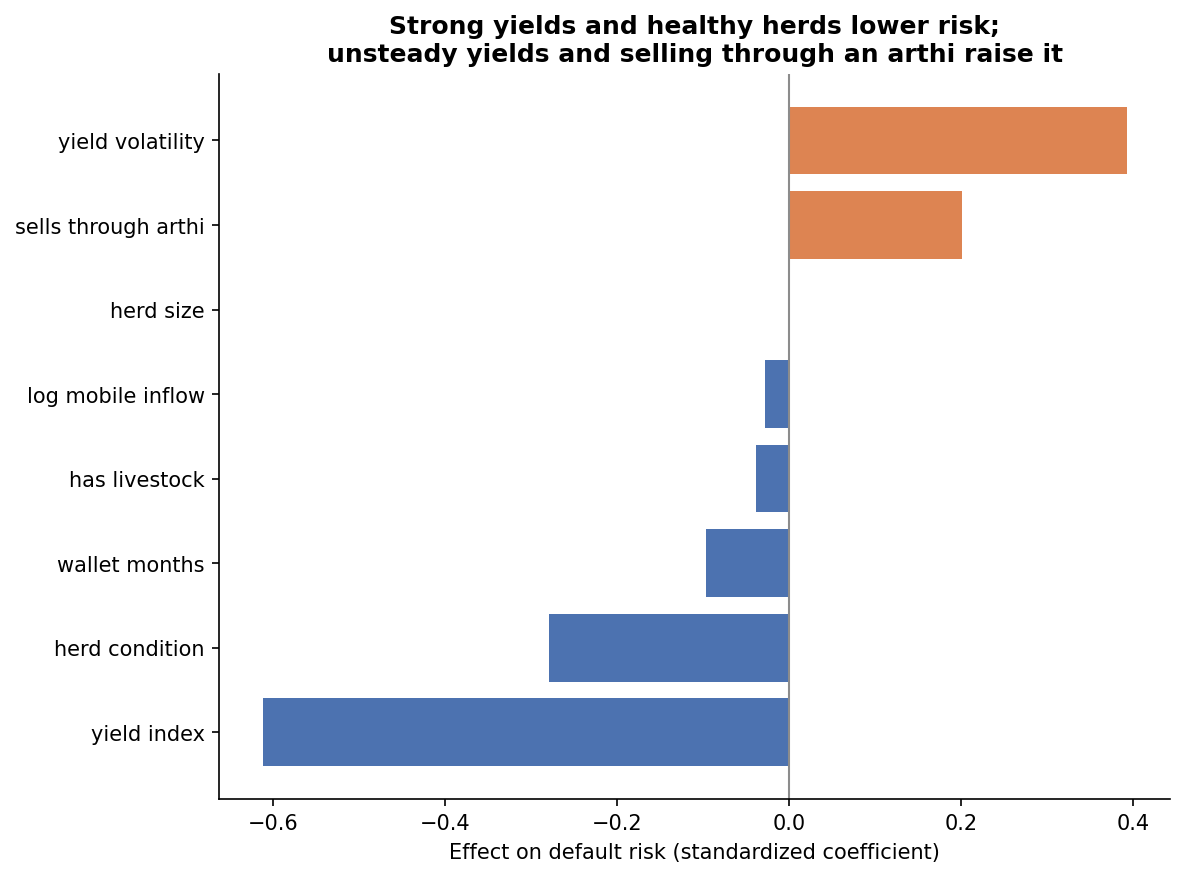

In [6]:
drivers = model.risk_drivers(fitted, model.FEATURES)
charts.drivers_chart(drivers, "../outputs/risk_drivers.png")
display(Image("../outputs/risk_drivers.png"))

## 5. From probability to score and offer

Standard scorecard scaling: a score of 600 means 20 farmers repay for every one who defaults, and every 40 points doubles those odds. Offers go up to 35% of expected seasonal income and are structured as Murabaha (inputs sold at an agreed markup) or Ijarah (a solar pump lease) instead of interest-bearing loans.

In [7]:
sample = test.head(8)
offers = [scorecard.financing_offer(row, p, cutoff) for (_, row), p in zip(sample.iterrows(), pd_test[:8])]
table = sample[["farmer_id", "land_acres", "has_land_title", "irrigation"]].reset_index(drop=True)
table["probability_of_default"] = pd_test[:8].round(3)
table["score"] = scorecard.to_score(pd_test[:8])
pd.concat([table, pd.DataFrame(offers)], axis=1)

,farmer_id,land_acres,has_land_title,irrigation,probability_of_default,score,decision,structure,limit_pkr
0,F02743,2.4,False,diesel_tubewell,0.137,533,approve,Ijarah: solar pump lease,69000
1,F03518,3.9,False,diesel_tubewell,0.510,425,decline,,0
2,F04004,17.4,True,canal,0.104,551,approve,Murabaha: seed and fertilizer,386000
3,F01500,1.9,False,diesel_tubewell,0.059,587,approve,Ijarah: solar pump lease,125000
4,F02212,7.7,True,canal,0.169,519,approve,Murabaha: seed and fertilizer,265000
5,F02903,7.9,True,diesel_tubewell,0.214,502,decline,,0
6,F00298,3.2,True,canal,0.503,426,decline,,0
7,F04765,8.9,False,canal,0.053,593,approve,Murabaha: seed and fertilizer,230000


## Limits and next steps

- **The data is simulated.** The relationships were built in, so the results show the pipeline works, not that farm data predicts repayment in the real world. That needs real repayment records.
- **Collateral does a different job.** Land lets a lender recover losses after a default; this prototype only models who is likely to default.
- **Next:** train on real lender data; score herd condition from phone photos; estimate yields from satellite imagery; check approvals for fairness across districts and farm sizes; and have a Shariah board review the Murabaha and Ijarah structures.